# Named Entity Recognition Classification

This notebook builds and evaluates supervised named entity recognition models using token-level linguistic features and word embeddings.

It compares feature-based SVM models on CoNLL-style data and an annotated NER dataset, with analysis of class imbalance and per-label performance.

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
from nltk.corpus.reader import ConllCorpusReader
train = ConllCorpusReader(str(PROJECT_ROOT / 'data' / 'raw' / 'CONLL2003'), 'train.txt', ['words', 'pos', 'ignore', 'chunk'])
training_features = []
training_gold_labels = []

for token, pos, ne_label in train.iob_words():
    a_dict = {
        'token': token,
        'pos': pos
    }
    training_features.append(a_dict)
    training_gold_labels.append(ne_label)
training_features[0:10]

[{'token': 'EU', 'pos': 'NNP'},
 {'token': 'rejects', 'pos': 'VBZ'},
 {'token': 'German', 'pos': 'JJ'},
 {'token': 'call', 'pos': 'NN'},
 {'token': 'to', 'pos': 'TO'},
 {'token': 'boycott', 'pos': 'VB'},
 {'token': 'British', 'pos': 'JJ'},
 {'token': 'lamb', 'pos': 'NN'},
 {'token': '.', 'pos': '.'},
 {'token': 'Peter', 'pos': 'NNP'}]

In [2]:
training_gold_labels[0:10]

['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O', 'B-PER']

In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
test = ConllCorpusReader(str(PROJECT_ROOT / 'data' / 'raw' / 'CONLL2003'), 'test.txt', ['words', 'pos', 'ignore', 'chunk'])

test_features = []
test_gold_labels = []
for token, pos, ne_label in test.iob_words():
    a_dict = {
        'token': token,
        'pos': pos
    }
    test_features.append(a_dict)
    test_gold_labels.append(ne_label)
test_features[0:10]

[{'token': 'SOCCER', 'pos': 'NN'},
 {'token': '-', 'pos': ':'},
 {'token': 'JAPAN', 'pos': 'NNP'},
 {'token': 'GET', 'pos': 'VB'},
 {'token': 'LUCKY', 'pos': 'NNP'},
 {'token': 'WIN', 'pos': 'NNP'},
 {'token': ',', 'pos': ','},
 {'token': 'CHINA', 'pos': 'NNP'},
 {'token': 'IN', 'pos': 'IN'},
 {'token': 'SURPRISE', 'pos': 'DT'}]

In [4]:
test_gold_labels[0:10]

['O', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'B-PER', 'O', 'O']

train size: 203621
test size: 46435


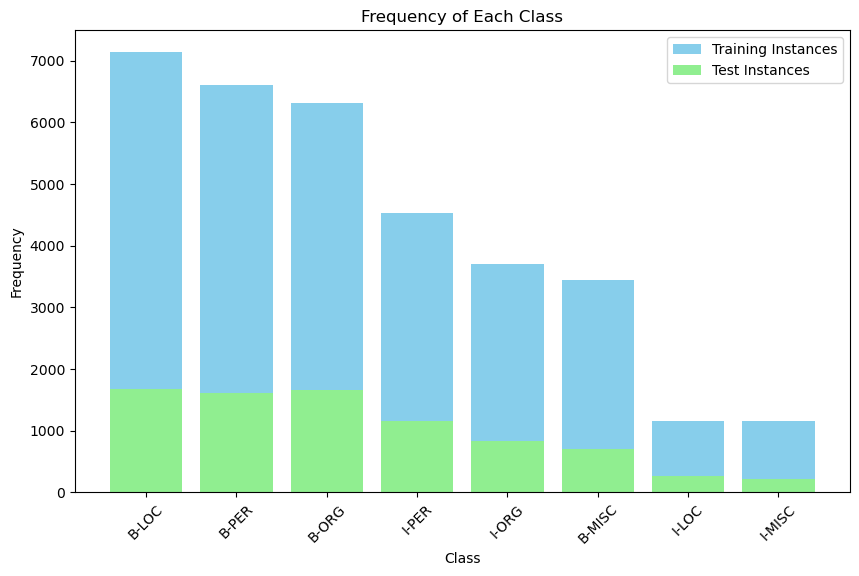

In [5]:
from collections import Counter
import matplotlib.pyplot as plt
print('train size:', len(training_features))
print('test size:', len(test_features))

train_count = Counter(training_gold_labels)
test_count = Counter(test_gold_labels)
classes = train_count.keys()

cumulative_freq = {class_label: train_count[class_label] + test_count[class_label] for class_label in classes}
sorted_classes = sorted(classes, key=lambda x: cumulative_freq[x], reverse=True)
sorted_classes = [c for c in sorted_classes if c != 'O']

train_counts_list = [train_count[class_label] for class_label in sorted_classes if class_label != 'O']
test_counts_list = [test_count[class_label] for class_label in sorted_classes if class_label != 'O']
#train_counts_list = [train_count[class_label] for class_label in sorted_classes]
#test_counts_list = [test_count[class_label] for class_label in sorted_classes]

plt.figure(figsize=(10, 6))
plt.bar(sorted_classes, train_counts_list, color='skyblue', label='Training Instances')
plt.bar(sorted_classes, test_counts_list, color='lightgreen', label='Test Instances')

plt.title('Frequency of Each Class')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.legend()
plt.show()

How many instances are in train and test?
train size: 203621
test size: 46435

Provide a frequency distribution of the NERC labels, i.e., how many times does each NERC label occur?
Here are all of the classes and their total occurrences ordered from highest to lowest

Class: O,      Training Instances: 169578 (81.5%), Test Instances: 38323  (18.5%),  Total occurrences: 207901
Class: B-LOC,  Training Instances: 7140 (81.1%),   Test Instances: 1668   (18.9%),  Total occurrences: 8808
Class: B-PER,  Training Instances: 6600 (80.3%),   Test Instances: 1617   (19.7%),  Total occurrences: 8217
Class: B-ORG,  Training Instances: 6321 (79.2%),   Test Instances: 1661   (20.8%),  Total occurrences: 7982
Class: I-PER,  Training Instances: 4528 (79.7%),   Test Instances: 1156   (20.3%),  Total occurrences: 5684
Class: I-ORG,  Training Instances: 3704 (81.6%),   Test Instances: 835    (18.4%),  Total occurrences: 4539
Class: B-MISC, Training Instances: 3438 (83.1%),   Test Instances: 702    (16.9%),  Total occurrences: 4140
Class: I-LOC,  Training Instances: 1157 (81.8%),   Test Instances: 257    (18.2%),  Total occurrences: 1414
Class: I-MISC, Training Instances: 1155 (84.2%),   Test Instances: 216    (15.8%),  Total occurrences: 1371

Discuss to what extent the training and test data is balanced (equal amount of instances for each NERC label) and to what extent the training and test data differ?

We can see that there are some classes such as B-LOChas a significantly larger ammount to total instances than the other classes and share around the same level. This causes the dataset to be unbalanced as it has a overwhelming number of occurences. However one thing to note is that the ratio between training and test instances seems to be around 80|20 split.

In [6]:
from sklearn.feature_extraction import DictVectorizer

In [7]:
vec = DictVectorizer()
the_array = training_features + test_features
vec_array = vec.fit_transform(the_array)

In [8]:
from sklearn import svm

In [9]:
lin_clf = svm.LinearSVC()

In [10]:
from sklearn.metrics import classification_report

x_train = vec_array[:203621]
x_test = vec_array[203621:]

lin_clf.fit(x_train, training_gold_labels)
y_pred = lin_clf.predict(x_test)

print(classification_report(test_gold_labels, y_pred))

/Users/javi/anaconda3/envs/TM/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


              precision    recall  f1-score   support

       B-LOC       0.81      0.78      0.79      1668
      B-MISC       0.78      0.66      0.72       702
       B-ORG       0.79      0.52      0.63      1661
       B-PER       0.86      0.44      0.58      1617
       I-LOC       0.62      0.53      0.57       257
      I-MISC       0.57      0.59      0.58       216
       I-ORG       0.70      0.47      0.56       835
       I-PER       0.33      0.87      0.48      1156
           O       0.98      0.98      0.98     38323

    accuracy                           0.92     46435
   macro avg       0.72      0.65      0.65     46435
weighted avg       0.94      0.92      0.92     46435



*NERC labels the classifier performs well on:*

O: The classifier has an F1-score of 0.98, which is extremely high. ‘O’ tags are much more common in the dataset (support = 38323), which gives the classifier a plethora of examples of how these tags look. 

B-PER: With an F1-score of 0.58, the results seem to suggest that the classifier is better at recognizing some classes than others. However, given that the precision is high, 0.86, while the recall is 0.44, it is safe to assume that while the classifier is rather accurate when it does predict B-PER, it fails to predict a great number of B-PER tags.

*NERC labels the classifier performs badly on:*

I-PER: With an F1-score of 0.48, the classifier seems to be underperforming I-PER. The precision of 0.33 combined with a high recall of 0.87 suggests that the classifier has a great amount of false positives. The classifier also has a balanced precision and recall, meaning that it both does not predict positives well and predicts bad predictions.

I-LOC and I-MISC: With F1-scores of 0.57 and 0.58, these are not particularly high, which suggests that the classifier does not predict these very well either. In other words, the classifier has issues predicting a considerable number of these NERC labels. The balanced precision and recall also suggest that the classifier neither does actually identify positives properly nor avoids false positives.

We believe that these performance differences are due to a few factors:

Class Imbalance: A more common class means a greater number of examples for the classifier to learn from, which results in better performance.

Entity Context: Some entities, such as B-LOC, may be much more recognizable on average. ‘I-’ prefaced entities can probably occur in a great larger number of indistinguishable contexts. 

Feature Representation: The features might not contain enough information to differentiate between such similar entity types, particularly those that require classifiers to learn context representation, particularly those of the ‘I-’ prefaced type. To improve, one could probably investigate slightly more fine-grained or descriptive features, which can even be learned from embeddings. We would also attempt to balance the dataset by selecting only a subset of the ‘O’ tag, such as resampling the data for training or using class weights during training.

In [11]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
from gensim.models import KeyedVectors

# Load pre-trained Word2Vec embeddings
word2vec_model = KeyedVectors.load_word2vec_format(str(PROJECT_ROOT / 'models' / 'GoogleNews-vectors-negative300.bin'), binary=True)

In [12]:
train_vectors=[]
train_labels=[]
for token, pos, ne_label in train.iob_words():

    if token!='' and token!='DOCSTART':
        if token in word2vec_model:
            vector=word2vec_model[token]
        else:
            vector=[0]*300
        train_vectors.append(vector)
        train_labels.append(ne_label)

test_vectors=[]
test_labels=[]
for token, pos, ne_label in test.iob_words():

    if token!='' and token!='DOCSTART':
        if token in word2vec_model:
            vector=word2vec_model[token]
        else:
            vector=[0]*300
        test_vectors.append(vector)
        test_labels.append(ne_label)

In [13]:
emb_model = svm.LinearSVC()
emb_model.fit(train_vectors, train_labels)

y_pred = emb_model.predict(test_vectors)
print(classification_report(test_labels, y_pred))

/Users/javi/anaconda3/envs/TM/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


              precision    recall  f1-score   support

       B-LOC       0.76      0.80      0.78      1668
      B-MISC       0.72      0.70      0.71       702
       B-ORG       0.69      0.64      0.66      1661
       B-PER       0.75      0.67      0.71      1617
       I-LOC       0.51      0.42      0.46       257
      I-MISC       0.60      0.54      0.57       216
       I-ORG       0.48      0.33      0.39       835
       I-PER       0.59      0.50      0.54      1156
           O       0.97      0.99      0.98     38323

    accuracy                           0.93     46435
   macro avg       0.68      0.62      0.64     46435
weighted avg       0.92      0.93      0.92     46435



*Without word embeddings the classifier's performance on NERC labels:*

B-LOC: 0.79 F1-score
B-MISC: 0.72 F1-score
B-ORG: 0.63 F1-score
B-PER: 0.58 F1-score
I-LOC: 0.57 F1-score
I-MISC: 0.58 F1-score
I-ORG: 0.56 F1-score
I-PER: 0.48 F1-score
O: 0.98 F1-score

*With word embeddings the classifier's performance on NERC labels:*

B-LOC: 0.78 F1-score
B-MISC: 0.70 F1-score
B-ORG: 0.66 F1-score
B-PER: 0.61 F1-score
I-LOC: 0.57 F1-score
I-MISC: 0.55 F1-score
I-ORG: 0.37 F1-score
I-PER: 0.54 F1-score
O: 0.98 F1-score

*F1-score analysis:*
B-MISC: Slight decrease in the F1-score (0.72 to 0.70) when using word embeddings.
B-ORG: Improvement from 0.63 to 0.66 with embeddings.
B-PER: Slight increase in performance for the classifier using embeddings: F1-score of 0.58 to 0.61.
I-LOC: F1-score remained stable at 0.57, thus the embeddings did not significantly affect the classifier's ability to identify locations within named entities.
I-MISC: Small decline from 0.58 to 0.55 with embeddings, suggesting potential difficulty in spotting the nuances of 'I-MISC' entities.
I-ORG: I-ORG suffered from a significant decrease in F1-score (0.56 to 0.37). This indicates that it the classifier had a hard time with embedding representations for this class.
I-PER: F1-score improvement (0.48 to 0.54), indicating that embeddings maybe have given beneficial context that resulted in an improved of the classifier capabilities to recognize 'I-PER'.

The impact of word embeddings on classifier performance is a mixed bag across different entity types. While improvements were observed for some classes, others remained just as stable, and some declined in performance. Whether or not the use of pre-trained word embeddings improves classifier performance is complex and depends on factors such as the diversity of contexts in which entity types occur, as well as the degree to which the semantic information captured in the embeddings is relevant to each class. While word embeddings could lend semantic knowledge that is very helpful to a system, they could also provide, for example as in the case of generics, ambiguity between entity types that have less distinct boundaries.

In [14]:
import pandas as pd

/var/folders/2z/mrc2n32n4fgbhy797l7lk18c0000gn/T/ipykernel_14194/4080736814.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [15]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
try:
    kaggle_dataset = pd.read_csv(PROJECT_ROOT / 'data' / 'raw' / 'ner_dataset.csv', encoding='latin1')
except UnicodeDecodeError:
    print("There was an error decoding the CSV file. Please try a different encoding or handle the issue manually.")

In [16]:
len(kaggle_dataset)

1048575

In [17]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

vec = DictVectorizer()
dict_data = kaggle_dataset[['Word', 'POS']].to_dict(orient='records')
vec_data = vec.fit_transform(dict_data)

df_train = vec_data[:838861]
df_test = vec_data[838861:]
#df_train = vec_data[:100000]
#df_test = vec_data[100000:120000]

df_train_imp = imputer.fit_transform(df_train)
df_test_imp = imputer.fit_transform(df_test)


y_train = kaggle_dataset[['Tag']][:838861]
y_test = kaggle_dataset[['Tag']][838861:]

print(df_train.shape, df_test.shape)

(838861, 35220) (209714, 35220)


In [18]:
clf = svm.LinearSVC()

clf.fit(df_train_imp, y_train)
y_pred = clf.predict(df_test_imp)

print(classification_report(y_test, y_pred))

/Users/javi/anaconda3/envs/TM/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/javi/anaconda3/envs/TM/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/javi/anaconda3/envs/TM/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/javi/anaconda3/envs/TM/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precisi

              precision    recall  f1-score   support

       B-art       0.21      0.07      0.11        82
       B-eve       0.58      0.30      0.40        46
       B-geo       0.79      0.86      0.82      7558
       B-gpe       0.99      0.95      0.97      3244
       B-nat       0.49      0.46      0.47        48
       B-org       0.70      0.50      0.58      4083
       B-per       0.80      0.65      0.72      3324
       B-tim       0.87      0.76      0.81      4110
       I-art       0.07      0.02      0.04        43
       I-eve       0.53      0.18      0.27        44
       I-geo       0.75      0.62      0.68      1409
       I-gpe       0.76      0.65      0.70        40
       I-nat       0.00      0.00      0.00        12
       I-org       0.74      0.55      0.63      3471
       I-per       0.56      0.83      0.67      3335
       I-tim       0.63      0.12      0.21      1308
           O       0.98      1.00      0.99    177557

    accuracy              

/Users/javi/anaconda3/envs/TM/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The SVM model demonstrated its capacity to accurately categorize cases by achieving a 95% accuracy on the test data. The macro average F1-score of 0.53 reveals differences in performance between classes since its a neutral score. For some labels, such as geopolitical entities (B-gpe), the model performs well; but, for other labels, such as artifact entities (B-art), it performs poorly. However the weighted average F1-score of 0.95 indicates great overall performance. This suggests that while the model excels in certain named entity identification tasks, but not too great in others.